In [23]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time
import os
from scipy.optimize import curve_fit
import B00_codes.dataReader as dr
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
import matplotlib.colors as mcolors
import json
from scipy.special import jn
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from lmfit import Model, Parameters, minimize
from scipy.integrate import dblquad
from matplotlib.colors import to_rgba
pi = np.pi

def exp_decay(t, tau):
    return np.exp(- t/tau)

def get_dissipative_part(rho, L1, L2):
        """
        Both L1 and L2 are Hermitian
        """
        C = rho @ L2
        C_dagger = C.conj().T
        C = C - C_dagger #computes [rho, L2]
        C = L1 @ C
        C_dagger = C.conj().T

        return 0.5 * (C + C_dagger)

def Dyn_rho_2qubits(t, rho_vec, 
                    H, L, gamma_d, sigma_1z, sigma_2z):
    rho = np.reshape(rho_vec, (4, 4))

    #coherent part
    C = H @ rho
    C_dagger = C.conj().T
    drhodt = - 1j * (C - C_dagger)

    #Correlated dissipation 
    drhodt += get_dissipative_part(rho, L, L) + \
        gamma_d[0, 0] * get_dissipative_part(rho, sigma_1z, sigma_1z) + \
        gamma_d[0, 1] * get_dissipative_part(rho, sigma_1z, sigma_2z) + \
        gamma_d[1, 0] * get_dissipative_part(rho, sigma_2z, sigma_1z) + \
        gamma_d[1, 1] * get_dissipative_part(rho, sigma_2z, sigma_2z)
        

    return drhodt.flatten()

sigma_mn = np.array([[0, 0], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

sigma_1mn = np.kron(np.eye(2), sigma_mn)
sigma_1pl = sigma_1mn.T

sigma_2mn = np.kron(sigma_mn, np.eye(2))
sigma_2pl = sigma_2mn.T

sigma_1z = np.kron(np.eye(2), sigma_z)
sigma_2z = np.kron(sigma_z, np.eye(2))


phi1 = np.array([1, 0, 0, 0], dtype=complex)#symmetric up-up state
phi2 = np.array([0, 1 / np.sqrt(2), 1 / np.sqrt(2), 0], dtype=complex)#symmetric up-dn state
phi3 = np.array([0, 0, 0, 1], dtype=complex)#symmetric dn-dn state
psi = np.array([0, 1 / np.sqrt(2), -1 / np.sqrt(2), 0], dtype=complex)#anti-symmetric up-dn state
 

In [24]:
#Parameters
delta_2z = 0   #detuning on NV_2
phi = -pi/2
amp_1 = 1.012 * np.exp(1j * phi) # 1.012
amp_2 = 1.115 * np.exp(1j * phi) # 1.115
tau_c = 0.1; Tmax=3000

# t_span = [0, Tmax] 
# t_eval = np.logspace(-2, np.log10(Tmax), 5000); t_eval[-1]=Tmax

rho = np.array([[1, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0], 
                [0, 0, 0, 0]],dtype=complex)
rho_vec = rho.flatten()


In [25]:
# s1s2=4.5
# # xt0 = t_eval; yt0 = sz1sz2_t/4/s1s2
# xt = t_eval; yt = sz1sz2_t/4/s1s2
# # xt2 = t_eval; yt2 = sz1sz2_t/4/s1s2

# Global fit the data

In [26]:
folder = 'C:/Users/lukin2dmaterials/data/forDeliv/'
file = 'T1SCCRRNoise_batch33_corr_thres25.txt'; path = folder + file; loaded = np.loadtxt(path)
x=loaded[:,0]; ys=loaded[:,1]; yr=loaded[:,2]; errs=loaded[:,3]; errr=loaded[:,4]
idx = np.argsort(x)
x=x[idx]; ys=ys[idx]; yr=yr[idx]; errs=errs[idx]; errr=errr[idx]

file = 'T1SCCRRNoise_batch2425263132_cleaned.txt'; path = folder + file; loaded = np.loadtxt(path)
x2=loaded[:,0]; y2=loaded[:,1]; err2=loaded[:,2]
idx = np.argsort(x2)
x2=x2[idx]; y2=y2[idx]; err2=err2[idx]
x2[6] = 0.6; x2[7] = 0.64

file = 'T1SCCRRNoise_batch181920b_corr_thres.txt'; path = folder + file; loaded = np.loadtxt(path)
x0 = loaded[:,0]; ys0 = loaded[:,1]; errs0 = loaded[:,2]
idx = np.argsort(x0)
x0=x0[idx]; ys0=ys0[idx]; errs0=errs0[idx]
file = 'T1SCCRRNoise_batch20a21a_acorr_thres.txt'; path = folder + file; loaded = np.loadtxt(path)
xr0 = loaded[:,0]; yr0 = loaded[:,1]; errr0 = loaded[:,2]
idx = np.argsort(xr0)
xr0=xr0[idx]; yr0=yr0[idx]; errr0=errr0[idx]

y = ((ys/errs**2) - (yr/errr**2))/((1/errs**2) + (1/errr**2))    
err = np.sqrt(1/((1/errs**2) + (1/errr**2)))

y0 = ((ys0/errs0**2) - (yr0/errr0**2))/((1/errs0**2) + (1/errr0**2))    
err0 = np.sqrt(1/((1/errs0**2) + (1/errr0**2)))

t_eval = x; t_eval0 = x0; t_eval2 = x2


In [27]:
def f(t_eval, A, gd):
    t_span = [0,t_eval[-1]+1]
    delta_1z = 0.25*2*pi #detuning on NV_1
    gamma_d_11 = gd
    gamma_d_22 = gamma_d_11
    gamma_d_12 = 0. #should be real, represents correlated dephasing
    gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

    H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
    L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
        amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
        amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
        )
    
    solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
                     t_span=t_span, 
                     y0=rho_vec, 
                     t_eval=t_eval,  # specify the evaluation points
                     method='RK45', 
                     atol=1e-10, 
                     rtol=1e-10)
    sz1_t = np.zeros_like(t_eval, dtype=complex)
    sz2_t = np.zeros_like(t_eval, dtype=complex)
    sz1sz2_t = np.zeros_like(t_eval, dtype=complex)

    for ind_t in range(len(t_eval)):
        rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
        sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
        sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
        sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]
    sz1sz2_t = sz1sz2_t.real
    return sz1sz2_t*A

def f0(t_eval0, A, gd0):
    t_span = [0,t_eval0[-1]+1]
    delta_1z = 0
    gamma_d_11 = gd0
    gamma_d_22 = gamma_d_11
    gamma_d_12 = 0. #should be real, represents correlated dephasing
    gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

    H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
    L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
        amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
        amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
        )
    
    solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
                     t_span=t_span, 
                     y0=rho_vec, 
                     t_eval=t_eval0,  # specify the evaluation points
                     method='RK45', 
                     atol=1e-10, 
                     rtol=1e-10)
    sz1_t = np.zeros_like(t_eval0, dtype=complex)
    sz2_t = np.zeros_like(t_eval0, dtype=complex)
    sz1sz2_t = np.zeros_like(t_eval0, dtype=complex)

    for ind_t in range(len(t_eval0)):
        rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
        sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
        sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
        sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]
    sz1sz2_t = sz1sz2_t.real
    return sz1sz2_t*A

def f2(t_eval2, A, gd2):
    idx = np.argsort(t_eval2); t_eval2 = t_eval2[idx]
    t_span = [0,t_eval2[-1]+1]
    delta_1z = 0.5*2*pi #detuning on NV_1
    gamma_d_11 = gd2
    gamma_d_22 = gamma_d_11
    gamma_d_12 = 0. #should be real, represents correlated dephasing
    gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

    H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
    L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
        amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
        amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
        )
    
    solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
                     t_span=t_span, 
                     y0=rho_vec, 
                     t_eval=t_eval2,  # specify the evaluation points
                     method='RK45', 
                     atol=1e-10, 
                     rtol=1e-10)
    sz1_t = np.zeros_like(t_eval2, dtype=complex)
    sz2_t = np.zeros_like(t_eval2, dtype=complex)
    sz1sz2_t = np.zeros_like(t_eval2, dtype=complex)

    for ind_t in range(len(t_eval2)):
        rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
        sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
        sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
        sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]
    sz1sz2_t = sz1sz2_t.real
    return sz1sz2_t*A

# Define objective function
def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
    A = params['A'].value
    gd0 = params['gd0'].value
    gd  = params['gd'].value
    gd2 = params['gd2'].value
    res0 = y0 - f0(t_eval0, A, gd0)
    res  = y -  f(t_eval, A, gd)
    res2 = y2 - f2(t_eval2, A, gd2)
    return np.concatenate((res0, res, res2))  # Combine residuals

# Define shared and unique parameters
if True:
    params = Parameters()
    params.add('A', value=0.03, min=0.02,max=0.06)
    params.add('gd0', value=0.12, min = 0.01,max=0.4)  
    params.add('gd', value=0.12, min = 0.01, max=0.4)
    params.add('gd2', value=0.12, min = 0.01,max=0.4) 

In [28]:
# # No gds
# def f(t_eval, A, gd=0):
#     t_span = [0,t_eval[-1]+1]
#     delta_1z = 0.25*2*pi #detuning on NV_1
#     gamma_d_11 = gd
#     gamma_d_22 = gamma_d_11
#     gamma_d_12 = 0. #should be real, represents correlated dephasing
#     gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

#     H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
#     L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
#         amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
#         amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
#         )
    
#     solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
#                      t_span=t_span, 
#                      y0=rho_vec, 
#                      t_eval=t_eval,  # specify the evaluation points
#                      method='RK45', 
#                      atol=1e-10, 
#                      rtol=1e-10)
#     sz1_t = np.zeros_like(t_eval, dtype=complex)
#     sz2_t = np.zeros_like(t_eval, dtype=complex)
#     sz1sz2_t = np.zeros_like(t_eval, dtype=complex)

#     for ind_t in range(len(t_eval)):
#         rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
#         sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
#         sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
#         sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]
#     sz1sz2_t = sz1sz2_t.real
#     return sz1sz2_t*A

# def f0(t_eval0, A, gd0=0):
#     t_span = [0,t_eval0[-1]+1]
#     delta_1z = 0
#     gamma_d_11 = gd0
#     gamma_d_22 = gamma_d_11
#     gamma_d_12 = 0. #should be real, represents correlated dephasing
#     gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

#     H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
#     L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
#         amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
#         amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
#         )
    
#     solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
#                      t_span=t_span, 
#                      y0=rho_vec, 
#                      t_eval=t_eval0,  # specify the evaluation points
#                      method='RK45', 
#                      atol=1e-10, 
#                      rtol=1e-10)
#     sz1_t = np.zeros_like(t_eval0, dtype=complex)
#     sz2_t = np.zeros_like(t_eval0, dtype=complex)
#     sz1sz2_t = np.zeros_like(t_eval0, dtype=complex)

#     for ind_t in range(len(t_eval0)):
#         rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
#         sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
#         sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
#         sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]
#     sz1sz2_t = sz1sz2_t.real
#     return sz1sz2_t*A

# def f2(t_eval2, A, gd2=0):
#     idx = np.argsort(t_eval2); t_eval2 = t_eval2[idx]
#     t_span = [0,t_eval2[-1]+1]
#     delta_1z = 0.5*2*pi #detuning on NV_1
#     gamma_d_11 = gd2
#     gamma_d_22 = gamma_d_11
#     gamma_d_12 = 0. #should be real, represents correlated dephasing
#     gamma_d = np.array([[gamma_d_11, gamma_d_12], [gamma_d_12, gamma_d_22]])#dephasing matrix

#     H = 0.5 * delta_1z * sigma_1z + 0.5 * delta_2z * sigma_2z
#     L = (2 * np.pi)**0.25 * np.sqrt(tau_c) * (
#         amp_1 * sigma_1pl + np.conjugate(amp_1) * sigma_1mn +
#         amp_2 * sigma_2pl + np.conjugate(amp_2) * sigma_2mn
#         )
    
#     solution = solve_ivp(lambda t, y: Dyn_rho_2qubits(t, y, H, L, gamma_d, sigma_1z, sigma_2z), 
#                      t_span=t_span, 
#                      y0=rho_vec, 
#                      t_eval=t_eval2,  # specify the evaluation points
#                      method='RK45', 
#                      atol=1e-10, 
#                      rtol=1e-10)
#     sz1_t = np.zeros_like(t_eval2, dtype=complex)
#     sz2_t = np.zeros_like(t_eval2, dtype=complex)
#     sz1sz2_t = np.zeros_like(t_eval2, dtype=complex)

#     for ind_t in range(len(t_eval2)):
#         rho_t = np.reshape(solution.y[:,ind_t], (4, 4))
#         sz1_t[ind_t] = np.trace(sigma_1z @ rho_t)
#         sz2_t[ind_t] = np.trace(sigma_2z @ rho_t)
#         sz1sz2_t[ind_t] = np.trace(sigma_1z @ sigma_2z @ rho_t) - sz1_t[ind_t] * sz2_t[ind_t]
#     sz1sz2_t = sz1sz2_t.real
#     return sz1sz2_t*A

# # Define objective function
# def objective(params, t_eval0, t_eval, t_eval2, y0,y,y2):
#     A = params['A'].value
#     gd0 = params['gd0'].value
#     gd  = params['gd'].value
#     gd2 = params['gd2'].value
#     res0 = y0 - f0(t_eval0, A, gd0)
#     res  = y -  f(t_eval, A, gd)
#     res2 = y2 - f2(t_eval2, A, gd2)
#     return np.concatenate((res0, res, res2))  # Combine residuals

# # Define shared and unique parameters
# if True:
#     params = Parameters()

#     params.add('A', value=0.03, min=0.02,max=0.06)
#     params.add('gd0', value=0, min = 0,max=0.001)  
#     params.add('gd', value=0, min = 0, max=0.001)
#     params.add('gd2', value=0, min = 0,max=0.001) 

In [29]:
# Fit data
if True:
    result = minimize(objective, params, args=(t_eval0, t_eval, t_eval2,  y0,y,y2))
    A = result.params['A'].value
    gd0 = result.params['gd0'].value; gd = result.params['gd'].value; gd2 = result.params['gd2'].value
    fitted_params = np.array([A,gd0,gd,gd2])

    Aerr = result.params['A'].stderr
    gd0err = result.params['gd0'].stderr; gderr = result.params['gd'].stderr; gd2err = result.params['gd2'].stderr
    fitted_params_err = np.array([Aerr,gd0err,gderr,gd2err])

    if np.any(fitted_params_err == None):
        fitted_params_err = np.array([1e6,1e6,1e6,1e6])
    
    ratios = fitted_params_err/fitted_params*100
    # sums[i,j]=np.sum(ratios)

    # Print results
    print(result.params.pretty_print())
    print(ratios)
    print(np.sum(ratios))


Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
A     0.04752     0.02     0.06 0.002472     True     None     None
gd     0.1887     0.01      0.4 0.008676     True     None     None
gd0     0.128     0.01      0.4  0.01526     True     None     None
gd2    0.1702     0.01      0.4   0.0491     True     None     None
None
[ 5.20206174 11.92622436  4.59666536 28.83779375]
50.56274521556424


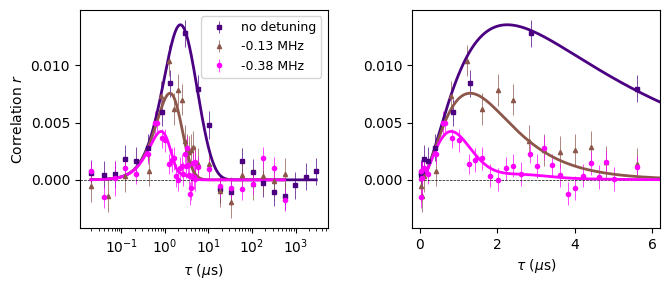

In [30]:
fig, axs = plt.subplots(1,2,figsize=(7,3)); ifAntiCorr=1; idx=7; ifFit=0

xt0 = np.logspace(np.log10(x0[0]),np.log10(x0[-1]),10001)
xt= np.logspace(np.log10(x[0]),np.log10(x[-1]),10001)
xt2 = np.logspace(np.log10(x2[0]),np.log10(x2[-1]),10001)
yt0 = f0(xt0,A,gd0); yt = f(xt,A,gd); yt2 = f2(xt2,A,gd2)
# ###############################################################################################
if True:
    axs[0].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[0].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[0].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta")
    axs[0].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[0].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[0].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[0].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)

    axs[1].errorbar(x0,y0,err0, marker='s',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='no detuning',color="#4B0082")
    axs[1].errorbar(x,y,err, marker='^',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.13 MHz',color="C5")
    axs[1].errorbar(x2,y2,err2, marker='o',linewidth=0.0, elinewidth=0.5,
                    markersize=3, label='-0.38 MHz',color="magenta",capsize=0)
    axs[1].hlines(y=0,xmin=0,xmax=max(x0),linestyle='--',color='k',linewidth=0.5)
    axs[1].plot(xt0, yt0, linewidth=2, markersize=3, color="#4B0082",label=None)
    axs[1].plot(xt, yt, linewidth=2, markersize=3, color='C5',label=None)
    axs[1].plot(xt2, yt2, linewidth=2, markersize=3, color='magenta',label=None)
    

    for i in range(2):
        axs[0].set_xscale('log')
        axs[1].set_xlim((-0.2,6.2))
        axs[i].set_xlabel('$\\tau$ ($\mu$s)')
        axs[0].set_ylabel('Correlation $r$')
        axs[0].legend(fontsize=9,loc='upper right')

    plt.tight_layout()

In [31]:
1/(4*A)

5.260439929514827